

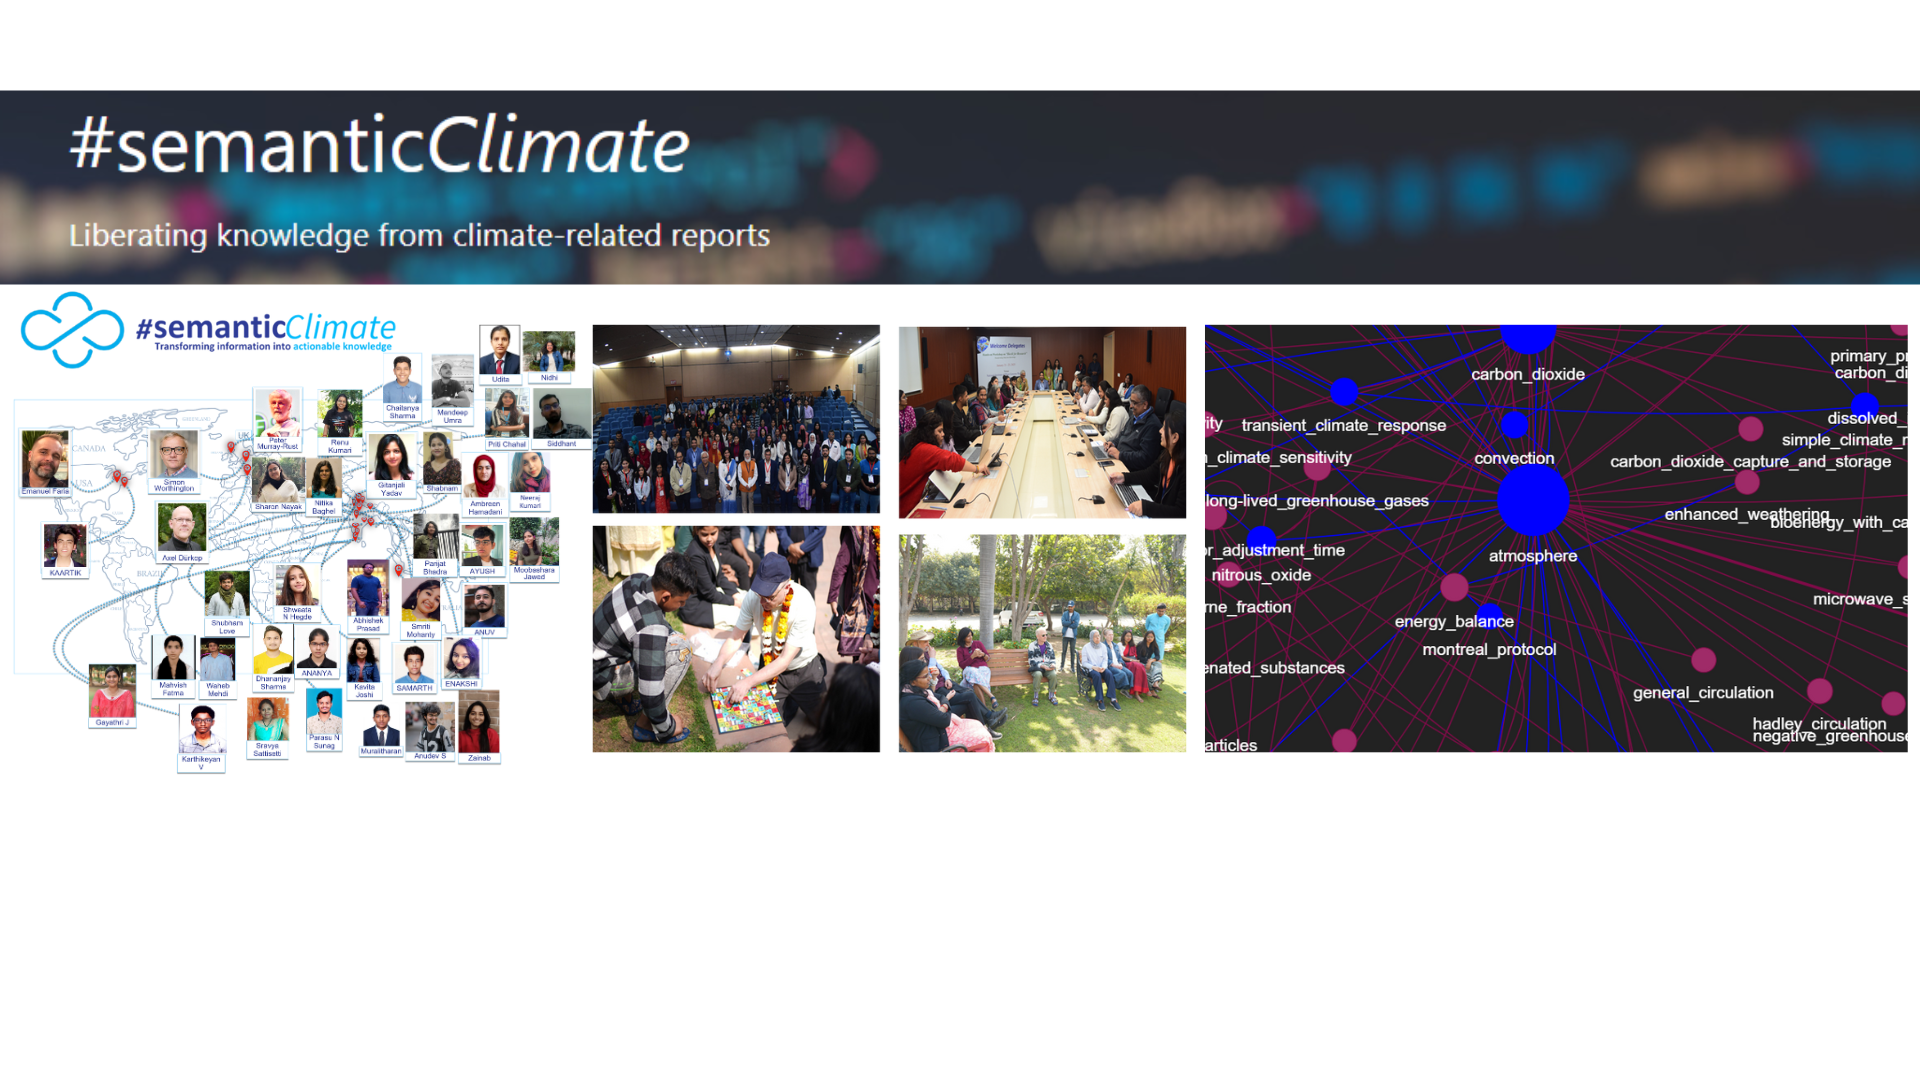



# This colab notebook describes the literature search on any query term and analyzing the results with the use of semanticClimate tools (`pygetpapers`, `amilib` and `docanalysis`)

## **Installation of semanticClimate toolkit ```pygetpapers``` and ```amilib```**


In [ ]:
!pip install --quiet pygetpapers
!pip install --quiet amilib==1.1.2

### **Get the number of articles from EPMC on any query**.

In [ ]:
!pygetpapers --query '"drug discovery" AND "medicinal plants"' -n

### **Temporal Distribution of Search Query in EPMC**.

In [ ]:
!pygetpapers --query '"drug discovery" AND "medicinal plants"' --xml -n --startdate "2010-01-01" --enddate "2025-10-31"

### **Download the 50 Most Recent Articles for a Search Query Within a Specific Time Frame**.
time taken: 1-3 minute

In [ ]:
!pygetpapers --query '"drug discovery" AND "medicinal plants"' --xml --limit 50 --startdate "2010-01-01" --enddate "2025-10-31" --output drug_discovery --save_query

### **Create Summary table for the retrieved articles**.

In [ ]:
!amilib HTML --operation DATATABLES --indir drug_discovery

## **Display Summary table in the Colab environment**

In [ ]:
from IPython.core.display import display, HTML

# Path to the HTML file
html_file_path = '/content/drug_discovery/datatables.html'

# Read the HTML file
with open(html_file_path, 'r', encoding='utf-8') as file:
    html_content = file.read()

# Display the HTML content
display(HTML(html_content))

## **Install ```docanalysis``` To extract entity like DRUG, Plant, Countries, Disease etc.**


In [ ]:
!pip install --quiet docanalysis==0.3.2 > /dev/null 2>&1

## **Verify the successful installation of the `docanalysis` run --help**

In [ ]:
!docanalysis --help

## **Extraction of Countries Mentioned in Specific Sections of Research Articles (Introduction, Results, Discussion, Conclusion, or Full Article)**

In [ ]:
!docanalysis --project_name drug_discovery --make_section --search_section INT, RES, CON, DIS --dictionary COUNTRY --output countries.csv

## **Display wordcloud for countries**

In [ ]:
# Import necessary libraries
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Colab download support
try:
    from google.colab import files
except ImportError:
    files = None

# Load CSV
csv_file_path = '/content/drug_discovery/countries.csv'
df = pd.read_csv(csv_file_path)

# Counter for row-level frequency
country_counter = Counter()

# Iterate row by row
for row in df['0'].dropna():
    # Split, clean, and normalize
    countries = [
        country.strip()
        for country in str(row).split(',')
        if country.strip()
    ]

    # IMPORTANT: remove duplicates within the same row
    unique_countries_in_row = set(countries)

    # Update global counter (1 per row)
    country_counter.update(unique_countries_in_row)

# Generate word cloud
wordcloud = WordCloud(
    width=900,
    height=450,
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(country_counter)

# Display
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Save
output_path = '/content/drug_discovery/country_wordcloud_row_frequency.png'
wordcloud.to_file(output_path)

# Download if in Colab
#if files:
#    files.download(output_path)

## **Extract Disease mentioned in the literature**

In [ ]:
!docanalysis --project_name drug_discovery --make_section --search_section INT, RES, CON, DIS --dictionary DISEASE --output disease.csv

## **Display wordcloud for Disease in Colab environment**

In [ ]:
# Import necessary libraries
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Colab download support
try:
    from google.colab import files
except ImportError:
    files = None

# Load CSV
csv_file_path = '/content/drug_discovery/disease.csv'
df = pd.read_csv(csv_file_path)

# Counter for row-level disease frequency
disease_counter = Counter()

# Iterate row by row
for row in df['0'].dropna():
    # Split comma-separated diseases and clean
    diseases = [
        disease.strip()
        for disease in str(row).split(',')
        if disease.strip()
    ]

    # IMPORTANT: count each disease only once per row
    unique_diseases_in_row = set(diseases)

    # Update global counter (row frequency)
    disease_counter.update(unique_diseases_in_row)

# Generate word cloud
wordcloud = WordCloud(
    width=900,
    height=450,
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(disease_counter)

# Display
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Save
output_path = '/content/drug_discovery/disease_wordcloud_row_frequency.png'
wordcloud.to_file(output_path)

# Download if running in Colab
#if files:
#    files.download(output_path)

## **Extract list of DRUGS mentioned in the literature.**.

In [ ]:
!docanalysis --project_name drug_discovery/ --make_section --search_section INT, RES, CON, DIS --dictionary DRUG --output drugs.csv

## **Display wordcloud for DRUGS in Colab environment**

In [ ]:
# Import necessary libraries
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from collections import Counter

# Colab download support
try:
    from google.colab import files
except ImportError:
    files = None

# Load CSV
csv_file_path = '/content/drug_discovery/drugs.csv'
df = pd.read_csv(csv_file_path)

# Counter for row-level drug frequency
drug_counter = Counter()

# Iterate row by row
for row in df['0'].dropna():
    # Split comma-separated drugs and clean
    drugs = [
        drug.strip()
        for drug in str(row).split(',')
        if drug.strip()
    ]

    # IMPORTANT: count each drug only once per row
    unique_drugs_in_row = set(drugs)

    # Update global counter (row frequency)
    drug_counter.update(unique_drugs_in_row)

# Generate word cloud
wordcloud = WordCloud(
    width=900,
    height=450,
    background_color='white',
    colormap='viridis'
).generate_from_frequencies(drug_counter)

# Display
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

# Save
output_path = '/content/drug_discovery/drug_wordcloud_row_frequency.png'
wordcloud.to_file(output_path)

# Download if running in Colab
#if files:
#    files.download(output_path)


# **WIKIDATA Enhancement of all the extracted entities**

In [ ]:
import pandas as pd
import requests
import time

# -------- INPUT CSVs --------
csv_files = {
    "countries": "/content/drug_discovery/countries.csv",
    "drugs": "/content/drug_discovery/drugs.csv",
    "diseases": "/content/drug_discovery/disease.csv"
}

# Load all CSVs
dfs = {}
for key, path in csv_files.items():
    try:
        dfs[key] = pd.read_csv(path)
        print(f"Loaded {key}: {path}")
    except Exception as e:
        print(f"Error loading {key}: {e}")
        dfs[key] = pd.DataFrame()  # Empty if failed

# -------- Cache for faster lookup --------
wikidata_cache = {}

def fetch_wikidata_ids(entity_text, retries=3):
    """
    Fetch Wikidata IDs for one or more comma-separated entity names.
    Returns all QIDs separated by commas.
    """
    if pd.isna(entity_text) or not str(entity_text).strip():
        return None

    names = [n.strip() for n in str(entity_text).split(",") if n.strip()]
    url = "https://www.wikidata.org/w/api.php"
    headers = {"User-Agent": "Drug_discovery/1.0 (mailto:example@domain.com)"}
    qids = []

    for name in names:
        # Use cache if already fetched
        if name in wikidata_cache:
            if wikidata_cache[name]:
                qids.append(wikidata_cache[name])
            continue

        params = {
            "action": "wbsearchentities",
            "format": "json",
            "language": "en",
            "limit": 1,
            "search": name
        }

        found_qid = None
        for attempt in range(retries):
            try:
                resp = requests.get(url, params=params, headers=headers, timeout=10)
                if resp.status_code != 200:
                    time.sleep(1)
                    continue
                data = resp.json()
                if "search" in data and len(data["search"]) > 0:
                    found_qid = data["search"][0]["id"]
                    break
            except Exception as e:
                print(f"⚠️ Error fetching {name}: {e}")
                time.sleep(1)

        wikidata_cache[name] = found_qid
        if found_qid:
            qids.append(found_qid)
        time.sleep(0.3)  # Avoid overloading the API

    return ", ".join(qids) if qids else None

# -------- Fetch Wikidata IDs and Update CSVs --------
for data_type, df in dfs.items():
    if df.empty or "0" not in df.columns:
        continue

    print(f"Fetching Wikidata IDs for {data_type}...")
    df["Wikidata_ID"] = df["0"].apply(fetch_wikidata_ids)

    # Save updated CSV
    updated_path = f"/content/drug_discovery/{data_type}_with_wikidata.csv"
    df.to_csv(updated_path, index=False)
    print(f"Updated {data_type} saved to: {updated_path}")

print("All CSVs updated with Wikidata_ID column.")

## **🌐 Integrated Network of Countries, Drugs, and Diseases with Wikidata and EPMC Connectivity**


In [ ]:
# =========================
# Colab: Cytoscape Network for Entities (Countries, Drugs, Diseases) with Wikidata Links
# =========================

# Install required libraries (Colab-safe)
!pip install networkx pandas

import pandas as pd
import re, json, os
import networkx as nx
from collections import defaultdict
from IPython.display import HTML, display

In [ ]:
# -------- INPUT CSVs (with Wikidata_ID) --------
csv_files = {
    "countries": "/content/drug_discovery/countries_with_wikidata.csv",
    "drugs": "/content/drug_discovery/drugs_with_wikidata.csv",
    "diseases": "/content/drug_discovery/diseases_with_wikidata.csv"
}

# Load all updated CSVs
dfs = {}
for key, path in csv_files.items():
    try:
        dfs[key] = pd.read_csv(path)
        print(f"Loaded updated {key}: {path}")
    except Exception as e:
        print(f"Error loading updated {key}: {e}")
        dfs[key] = pd.DataFrame()  # Empty if failed

# -------- Color Map --------
color_map = {
    "COUNTRY": "#e377c2",
    "DISEASE": "#7f7f7f",
    "DRUG": "#008000",
    "FILE": "#0055ff"
}

# -------- Build Network --------
all_edges = []
wikidata_map = {}

for data_type, df in dfs.items():
    if df.empty:
        continue

    dict_name = {
        "countries": "COUNTRY",
        "drugs": "DRUG",
        "diseases": "DISEASE"
    }.get(data_type, "Unknown")

    if "file_path" not in df.columns or "0" not in df.columns:
        print(f"⚠️ Skipped {data_type} (missing required columns: file_path or 0).")
        continue

    for _, row in df.iterrows():
        file_path = str(row["file_path"])
        match = re.search(r"(PMC\d+)", file_path)
        source = match.group(1) if match else os.path.basename(file_path)

        targets = str(row["0"]).split(",")
        weight = int(row["weight_0"]) if "weight_0" in df.columns else 1

        if "Wikidata_ID" in df.columns:
            wikidata_ids = str(row["Wikidata_ID"]).split(",") if pd.notna(row["Wikidata_ID"]) else []
            for i, target in enumerate(targets):
                t = target.strip()
                if t and i < len(wikidata_ids):
                    wikidata_id = wikidata_ids[i].strip()
                    if wikidata_id:
                        wikidata_map[t] = f"https://www.wikidata.org/wiki/{wikidata_id}"

        for target in targets:
            t = target.strip()
            if t:
                all_edges.append((source, t, weight, dict_name))

if not all_edges:
    print("No edges created — check your updated CSVs.")
else:
    G = nx.Graph()
    for s, t, w, d in all_edges:
        G.add_edge(s, t, weight=w, dict_name=d)

    print(f"Network created with {len(G.nodes())} nodes and {len(G.edges())} edges.")

    # -------- Save Network as GraphML --------
    graphml_path = "/content/drug_discovery/network.graphml"
    nx.write_graphml(G, graphml_path)
    print(f"✔ Network saved as GraphML: {graphml_path}")

    # -------- Convert to Cytoscape elements --------
    nodes = []
    for n in G.nodes():
        # ---------- PMC ARTICLE NODE ----------
        if n.startswith("PMC"):
            node_type = "FILE"
            color = color_map["FILE"]
            url = f"https://europepmc.org/articles/{n}"
        # ---------- ENTITY NODE ----------
        else:
            edge_dicts = [
                G[s][n]['dict_name']
                for s in G.neighbors(n)
                if 'dict_name' in G[s][n]
            ]
            node_type = edge_dicts[0] if edge_dicts else "Unknown"
            color = color_map.get(node_type, "#cccccc")
            url = wikidata_map.get(n)

        nodes.append({
            "data": {
                "id": n,
                "label": n,
                "type": node_type,
                "color": color,
                "url": url
            }
        })

    edges_cyto = [
        {"data": {"source": s, "target": t, "weight": d["weight"]}}
        for s, t, d in G.edges(data=True)
    ]

    elements = nodes + edges_cyto

    stylesheet = [
        {"selector": "node", "style": {
            "label": "data(label)",
            "background-color": "data(color)",
            "font-size": "10px",
            "text-valign": "center",
            "color": "#000000",
            "cursor": "pointer"
        }},
        {"selector": "edge", "style": {"width": 2, "curve-style": "bezier"}}
    ]

    layout_choice = "cose"  # Default layout; can be changed to "circle", "grid", etc.
    layout = {"name": layout_choice}

    # -------- Render Cytoscape.js --------
    elements_json = json.dumps(elements)
    stylesheet_json = json.dumps(stylesheet)
    layout_json = json.dumps(layout)

    display(HTML(f"""
    <html>
    <head>
      <script src="https://unpkg.com/cytoscape@3.21.2/dist/cytoscape.min.js"></script>
      <style>
        #message-box {{
          position: fixed;
          top: 20px;
          right: 20px;
          background-color: #ffefc1;
          color: #333;
          padding: 10px 15px;
          border-radius: 8px;
          font-family: sans-serif;
          box-shadow: 0px 0px 8px rgba(0,0,0,0.2);
          display: none;
          z-index: 9999;
        }}
      </style>
    </head>
    <body>
      <div id="cy" style="width:100%; height:700px; border:1px solid #ccc;"></div>
      <div id="message-box">⚠️ Wikidata page not available for this entity.</div>

      <script>
        const cy = cytoscape({{
          container: document.getElementById('cy'),
          elements: {elements_json},
          style: {stylesheet_json},
          layout: {layout_json}
        }});

        const messageBox = document.getElementById('message-box');

        function showMessage(msg) {{
          messageBox.innerText = msg;
          messageBox.style.display = 'block';
          setTimeout(() => {{
            messageBox.style.display = 'none';
          }}, 3000);
        }}

        cy.on('tap', 'node', function(evt) {{
          const node = evt.target;
          const url = node.data('url');
          const label = node.data('label');

          if (url) {{
            window.open(url, '_blank');
          }} else {{
            showMessage(`⚠️ Wikidata page not available for: ${{label}}`);
          }}
        }});
      </script>
    </body>
    </html>
    """))

##**Save all the Outputs in Local Machine**

In [ ]:
# Compress the folder into a ZIP file
!zip -r drug_discovery.zip /content/drug_discovery
from google.colab import files
files.download('/content/drug_discovery.zip')

## Created by : #semanticClimate
### License: CC BY

## References:
- [pygetpapers](https://github.com/petermr/pygetpapers)
- [amilib](https://github.com/petermr/amilib)
- [docanalysis](https://github.com/petermr/docanalysis)